# Task 3: Vector Space Model and Feature Representation

In this task I'm looking at different ways to turn text into numeric vectors that a classifier can actually use. 
The representations I'll be comparing are:

- **Binary** – just marks whether a word appears in a document or not
- **Bag of Words (frequency count)** – counts how many times each word appears
- **TF-IDF** – weighs word frequency against how common the word is across all documents
- **N-gram features** – extending all of the above to include word pairs (bigrams) and triples (trigrams)
- **Word Embeddings (Word2Vec)** – dense vectors that capture semantic meaning based on context

I'm keeping Logistic Regression as the model throughout so the only variable is the representation itself. 
This makes it easier to isolate what difference each representation actually makes.

In [1]:
# installing gensim if it's not already available - needed for Word2Vec
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'gensim', '-q'])


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

In [2]:
# importing everything needed upfront
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

# gensim is needed for Word2Vec
from gensim.models import Word2Vec

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/muhammadsaad/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/muhammadsaad/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/muhammadsaad/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/muhammadsaad/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

## Loading and Preprocessing the Data

I'm loading the English-filtered datasets that were produced in Task 1 and then re-applying the same
preprocessing pipeline from Task 2. I could have saved the processed text to a CSV but re-running 
it here keeps the notebook self-contained and easier to follow.

In [3]:
# loading the cleaned English-only datasets produced in Task 1
df_train = pd.read_csv('data/train_english.csv')
df_test  = pd.read_csv('data/test_english.csv')

print(f"Training samples: {len(df_train)}")
print(f"Test samples:     {len(df_test)}")
print(df_train.head(3))

Training samples: 271897
Test samples:     69907
                                                text  rating  text_length
0  This place is TERRIBLE; the people in charge a...       2          551
1  Terrible Service! And they are saying that I n...       1          258
2  Absolutely terrible company.  They sent me to ...       1         1180


In [4]:
# re-defining the preprocessing pipeline from Task 2 so this notebook runs on its own
# the logic is identical to what was used there

stop_words = set(stopwords.words('english'))
# keeping negation words in because they carry important sentiment information
# e.g. 'not good' is very different from 'good'
stop_words -= {'not', 'never', 'no', 'nor', 'none'}

lemmatizer = WordNetLemmatizer()

def remove_emojis(text):
    emoji_pattern = re.compile(
        "[" u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF" u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0" u"\U000024C2-\U0001F251"
        u"\U0001F900-\U0001F9FF" u"\U0001FA70-\U0001FAFF" "]+",
        flags=re.UNICODE
    )
    return emoji_pattern.sub('', text)

def handle_negations(text):
    text = re.sub(r"n't", " not", text)
    text = re.sub(r"won't", "will not", text)
    text = re.sub(r"can't", "cannot", text)
    return text

def preprocess(text):
    text = remove_emojis(str(text))
    text = re.sub(r'<.*?>', '', text)           # strip HTML tags
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # remove URLs
    text = text.lower()
    text = handle_negations(text)
    text = re.sub(r'[^\w\s]', '', text)         # remove punctuation
    tokens = word_tokenize(text)
    tokens = [w for w in tokens if w not in stop_words]
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    return " ".join(tokens)

print("Applying preprocessing to training set...")
df_train['processed'] = df_train['text'].apply(preprocess)
print("Applying preprocessing to test set...")
df_test['processed']  = df_test['text'].apply(preprocess)

X_train = df_train['processed']
X_test  = df_test['processed']
y_train = df_train['rating']
y_test  = df_test['rating']

print("Done.")
print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")

Applying preprocessing to training set...
Applying preprocessing to test set...
Done.
X_train shape: (271897,), X_test shape: (69907,)


In [5]:
# helper function to train logistic regression and return accuracy and weighted F1
# I'm keeping max_iter=1000 throughout so comparisons are fair
def evaluate(name, X_tr, X_te, y_tr=y_train, y_te=y_test):
    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_te)
    acc = accuracy_score(y_te, preds)
    f1  = f1_score(y_te, preds, average='weighted')
    print(f"{name:<40}  Accuracy: {acc:.4f}   F1 (weighted): {f1:.4f}")
    return acc, f1, preds

# store results for the final summary chart
results = {}

---
## 1. Binary Representation

Binary vectorization is the simplest possible representation. Each document becomes a vector where 
a position is 1 if the word is present and 0 if it is not. It completely ignores how many times 
a word appears, so 'great great great' and 'great' look identical to the model.

The trade-off is obvious: it loses frequency information, but it does avoid the issue of very common 
words dominating just because they appear a lot. For short reviews this might actually be fine because 
repeated words are less common anyway.

In [6]:
# binary=True makes CountVectorizer mark presence (1) or absence (0) instead of counting
binary_vec = CountVectorizer(max_features=10000, binary=True)
X_train_bin = binary_vec.fit_transform(X_train)
X_test_bin  = binary_vec.transform(X_test)

print(f"Binary matrix shape: {X_train_bin.shape}")
print(f"Each document is represented as a {X_train_bin.shape[1]}-dimensional sparse vector")

# quick sanity check - look at one document's non-zero entries
sample_idx = 0
sample_vec = X_train_bin[sample_idx]
feature_names = binary_vec.get_feature_names_out()
present_words = [feature_names[i] for i in sample_vec.indices]
print(f"\nSample review (first 10 words present): {present_words[:10]}")
print(f"Original text snippet: {X_train.iloc[0][:100]}")

Binary matrix shape: (271897, 10000)
Each document is represented as a 10000-dimensional sparse vector

Sample review (first 10 words present): ['place', 'terrible', 'people', 'charge', 'worst', 'part', 'far', 'yeah', 'beautiful', 'inside']
Original text snippet: place terrible people charge worst part far yeah place beautiful inside people running not director 


In [7]:
acc, f1, _ = evaluate("Binary (unigrams)", X_train_bin, X_test_bin)
results['Binary (unigrams)'] = (acc, f1)

Binary (unigrams)                         Accuracy: 0.6471   F1 (weighted): 0.6113


---
## 2. Bag of Words – Frequency Count

Bag of Words counts how often each word appears in a document. Unlike binary, it does capture 
the difference between mentioning 'bad' once versus ten times. The downside is that very common 
words like 'the' or 'place' can end up dominating the vector even if they don't carry much 
discriminative information – though removing stop words in Task 2 already helps a lot with that.

The model has no idea about word order, so 'not good' and 'good not' are treated the same. 
That is the fundamental limitation of all bag-of-words style models.

In [8]:
# standard CountVectorizer without binary flag gives raw term frequencies
bow_vec = CountVectorizer(max_features=10000)
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

print(f"BoW matrix shape: {X_train_bow.shape}")

# look at a sample to see the difference from binary
sample_bow = X_train_bow[0]
bow_names  = bow_vec.get_feature_names_out()
# get top 5 terms by count for this document
top_indices = sample_bow.toarray()[0].argsort()[-5:][::-1]
print("\nTop 5 terms by count in first review:")
for idx in top_indices:
    print(f"  '{bow_names[idx]}': {sample_bow[0, idx]}")

BoW matrix shape: (271897, 10000)

Top 5 terms by count in first review:
  'place': 3
  'director': 3
  'people': 2
  'bring': 2
  'yeah': 1


In [9]:
acc, f1, _ = evaluate("Bag of Words – frequency (unigrams)", X_train_bow, X_test_bow)
results['BoW Frequency (unigrams)'] = (acc, f1)

Bag of Words – frequency (unigrams)       Accuracy: 0.6458   F1 (weighted): 0.6085


---
## 3. TF-IDF Representation

TF-IDF (Term Frequency – Inverse Document Frequency) improves on raw counts by down-weighting 
words that appear in nearly every document. The idea is that if a word shows up everywhere 
it probably isn't very useful for distinguishing between classes.

For example, the word 'place' is very common across all ratings in this dataset (we saw this 
in Task 1). TF-IDF will give it a lower weight compared to a more distinctive word like 
'disgusting' or 'outstanding'.

I'll test unigrams first and then move on to the n-gram comparison section below.

In [10]:
tfidf_uni = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
X_train_tfidf = tfidf_uni.fit_transform(X_train)
X_test_tfidf  = tfidf_uni.transform(X_test)

print(f"TF-IDF matrix shape: {X_train_tfidf.shape}")

# show top weighted terms for the first review
tfidf_names = tfidf_uni.get_feature_names_out()
sample_tfidf = X_train_tfidf[0].toarray()[0]
top_tfidf_idx = sample_tfidf.argsort()[-5:][::-1]
print("\nTop 5 terms by TF-IDF weight in first review:")
for idx in top_tfidf_idx:
    print(f"  '{tfidf_names[idx]}': {sample_tfidf[idx]:.4f}")

TF-IDF matrix shape: (271897, 10000)

Top 5 terms by TF-IDF weight in first review:
  'director': 0.5344
  'bring': 0.2615
  'reevaluate': 0.2321
  'dedication': 0.2119
  'place': 0.2053


In [11]:
acc, f1, _ = evaluate("TF-IDF (unigrams)", X_train_tfidf, X_test_tfidf)
results['TF-IDF (unigrams)'] = (acc, f1)

TF-IDF (unigrams)                         Accuracy: 0.6595   F1 (weighted): 0.6194


---
## 4. N-gram Feature Comparison

So far everything above uses unigrams – individual words. The problem with unigrams is that 
phrases like 'not good' or 'highly recommend' get split into separate tokens, losing the 
meaning that comes from the combination.

N-grams address this by also treating consecutive word sequences as features:
- **Bigrams (1,2)**: includes unigrams and all two-word pairs
- **Trigrams (1,3)**: includes unigrams, bigrams, and three-word sequences

The trade-off is that the vocabulary grows very quickly with higher n, which means more memory 
and longer training time. I'll test all three and see if the extra complexity is worth it.

In [12]:
# unigrams only – already done above but repeating here for direct comparison
tfidf_1 = TfidfVectorizer(max_features=10000, ngram_range=(1, 1))
X_tr_1 = tfidf_1.fit_transform(X_train)
X_te_1 = tfidf_1.transform(X_test)

# unigrams + bigrams
tfidf_2 = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_tr_2 = tfidf_2.fit_transform(X_train)
X_te_2 = tfidf_2.transform(X_test)

# unigrams + bigrams + trigrams
# keeping max_features the same so it's a fair comparison
tfidf_3 = TfidfVectorizer(max_features=10000, ngram_range=(1, 3))
X_tr_3 = tfidf_3.fit_transform(X_train)
X_te_3 = tfidf_3.transform(X_test)

print(f"Unigrams vocab size:  {len(tfidf_1.vocabulary_)}")
print(f"Bigrams vocab size:   {len(tfidf_2.vocabulary_)}")
print(f"Trigrams vocab size:  {len(tfidf_3.vocabulary_)}")
print("\nAll three are capped at max_features=10000 so the size is the same,")
print("but the trigram vectorizer fills those 10000 slots with a different mix of features.")

Unigrams vocab size:  10000
Bigrams vocab size:   10000
Trigrams vocab size:  10000

All three are capped at max_features=10000 so the size is the same,
but the trigram vectorizer fills those 10000 slots with a different mix of features.


In [13]:
# show a sample of bigram and trigram features to see what they look like
bigram_features  = [f for f in tfidf_2.get_feature_names_out() if ' ' in f][:15]
trigram_features = [f for f in tfidf_3.get_feature_names_out() if f.count(' ') == 2][:10]

print("Sample bigram features:")
print(bigram_features)
print("\nSample trigram features:")
print(trigram_features)

Sample bigram features:
['10 day', '10 min', '10 minute', '10 month', '10 star', '10 time', '10 year', '100 dollar', '12 day', '12 hour', '12 month', '12 year', '14 day', '15 day', '15 hour']

Sample trigram features:
['answer phone call', 'asked speak manager', 'avoid place cost', 'awful customer service', 'back next day', 'bad customer service', 'best customer service', 'better business bureau', 'better customer service', 'ca not afford']


In [14]:
# evaluate all three n-gram configurations
acc1, f1_1, _ = evaluate("TF-IDF (1,1) – unigrams",           X_tr_1, X_te_1)
acc2, f1_2, _ = evaluate("TF-IDF (1,2) – unigrams + bigrams", X_tr_2, X_te_2)
acc3, f1_3, _ = evaluate("TF-IDF (1,3) – up to trigrams",     X_tr_3, X_te_3)

results['TF-IDF (1,1) unigrams']  = (acc1, f1_1)
results['TF-IDF (1,2) bigrams']   = (acc2, f1_2)
results['TF-IDF (1,3) trigrams']  = (acc3, f1_3)

TF-IDF (1,1) – unigrams                   Accuracy: 0.6595   F1 (weighted): 0.6194
TF-IDF (1,2) – unigrams + bigrams         Accuracy: 0.6682   F1 (weighted): 0.6309
TF-IDF (1,3) – up to trigrams             Accuracy: 0.6690   F1 (weighted): 0.6324


In [15]:
# also run the same n-gram comparison on Bag of Words to see if the trend holds there too
bow_1 = CountVectorizer(max_features=10000, ngram_range=(1, 1))
bow_2 = CountVectorizer(max_features=10000, ngram_range=(1, 2))
bow_3 = CountVectorizer(max_features=10000, ngram_range=(1, 3))

acc_b1, f1_b1, _ = evaluate("BoW (1,1) – unigrams",           bow_1.fit_transform(X_train), bow_1.transform(X_test))
acc_b2, f1_b2, _ = evaluate("BoW (1,2) – unigrams + bigrams", bow_2.fit_transform(X_train), bow_2.transform(X_test))
acc_b3, f1_b3, _ = evaluate("BoW (1,3) – up to trigrams",     bow_3.fit_transform(X_train), bow_3.transform(X_test))

results['BoW (1,1) unigrams'] = (acc_b1, f1_b1)
results['BoW (1,2) bigrams']  = (acc_b2, f1_b2)
results['BoW (1,3) trigrams'] = (acc_b3, f1_b3)

BoW (1,1) – unigrams                      Accuracy: 0.6458   F1 (weighted): 0.6085
BoW (1,2) – unigrams + bigrams            Accuracy: 0.6544   F1 (weighted): 0.6211
BoW (1,3) – up to trigrams                Accuracy: 0.6547   F1 (weighted): 0.6213


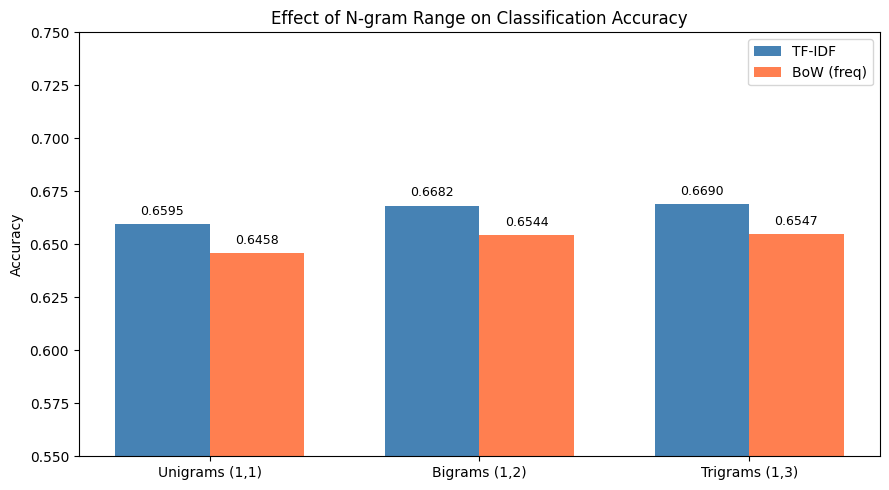

In [16]:
# plot the n-gram comparison side by side for both TF-IDF and BoW
ngram_labels = ['Unigrams (1,1)', 'Bigrams (1,2)', 'Trigrams (1,3)']
tfidf_accs = [acc1, acc2, acc3]
bow_accs   = [acc_b1, acc_b2, acc_b3]

x = np.arange(len(ngram_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, tfidf_accs, width, label='TF-IDF', color='steelblue')
bars2 = ax.bar(x + width/2, bow_accs,   width, label='BoW (freq)', color='coral')

ax.set_ylabel('Accuracy')
ax.set_title('Effect of N-gram Range on Classification Accuracy')
ax.set_xticks(x)
ax.set_xticklabels(ngram_labels)
ax.legend()
ax.set_ylim(0.55, 0.75)

# add value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

---
## 5. Word Embeddings – Word2Vec

All the representations above are sparse vectors where most entries are zero. They also treat 
every word as completely independent of every other – so 'excellent' and 'outstanding' are as 
different as 'excellent' and 'terrible', which is clearly not ideal.

Word2Vec learns dense, low-dimensional vectors for each word based on the surrounding context 
in which it appears (the 'you shall know a word by the company it keeps' idea). Words that 
appear in similar contexts end up with similar vectors.

To get a single vector for an entire review I'm averaging the word vectors together. This is 
a simple and common approach – more sophisticated options exist (like Doc2Vec) but this is a 
good starting point to see whether semantic embeddings help.

I'm training Word2Vec on the training corpus rather than using pre-trained vectors because 
the vocabulary in customer reviews is quite domain-specific.

In [17]:
# Word2Vec expects a list of token lists, not strings
print("Tokenizing for Word2Vec...")
train_tokens = [text.split() for text in X_train]
test_tokens  = [text.split() for text in X_test]

# vector_size: dimensionality of the word vectors
# window: context window size – how many words either side to consider
# min_count: ignore words that appear fewer than this many times
# workers: parallel threads
# sg=1 uses Skip-Gram which tends to work better for smaller datasets
print("Training Word2Vec model...")
w2v_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    seed=42
)

print(f"Vocabulary size: {len(w2v_model.wv.key_to_index)} words")
print(f"Vector dimension: {w2v_model.vector_size}")

Tokenizing for Word2Vec...
Training Word2Vec model...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Vocabulary size: 41296 words
Vector dimension: 100


In [18]:
# quick check - similar words to 'good' and 'terrible' to see if the model learned sensible relationships
print("Most similar words to 'good':")
print(w2v_model.wv.most_similar('good', topn=8))

print("\nMost similar words to 'terrible':")
print(w2v_model.wv.most_similar('terrible', topn=8))

Most similar words to 'good':
[('great', 0.851528525352478), ('decent', 0.8257189989089966), ('alright', 0.7743999361991882), ('ok', 0.7515127062797546), ('excellent', 0.7460311055183411), ('okay', 0.7458773851394653), ('rarity', 0.7334086298942566), ('goodbut', 0.7298556566238403)]

Most similar words to 'terrible':
[('horrible', 0.9494792222976685), ('awful', 0.9225654006004333), ('poor', 0.8304552435874939), ('aweful', 0.8167683482170105), ('horrendous', 0.8036269545555115), ('atrocious', 0.8026631474494934), ('horrific', 0.7975368499755859), ('horriable', 0.793347954750061)]


In [19]:
# function to create a document vector by averaging the word vectors in the review
# if none of the words are in the vocabulary the document gets a zero vector
def document_vector(tokens, model, vector_size=100):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

print("Creating document vectors for training set...")
X_train_w2v = np.array([document_vector(tokens, w2v_model) for tokens in train_tokens])
print("Creating document vectors for test set...")
X_test_w2v  = np.array([document_vector(tokens, w2v_model) for tokens in test_tokens])

print(f"Training matrix shape: {X_train_w2v.shape}")
print(f"Test matrix shape:     {X_test_w2v.shape}")
print("\nUnlike the sparse BoW/TF-IDF matrices, this is a dense 100-dimensional vector per review.")

Creating document vectors for training set...
Creating document vectors for test set...
Training matrix shape: (271897, 100)
Test matrix shape:     (69907, 100)

Unlike the sparse BoW/TF-IDF matrices, this is a dense 100-dimensional vector per review.


In [20]:
acc, f1, _ = evaluate("Word2Vec (avg pooling, 100d)", X_train_w2v, X_test_w2v)
results['Word2Vec (avg, 100d)'] = (acc, f1)

Word2Vec (avg pooling, 100d)              Accuracy: 0.6350   F1 (weighted): 0.5752


In [21]:
# also try with larger vector size to see if more dimensions help
print("Training Word2Vec with 300-dimensional vectors...")
w2v_300 = Word2Vec(
    sentences=train_tokens,
    vector_size=300,
    window=5,
    min_count=3,
    workers=4,
    sg=1,
    seed=42
)

X_train_w2v_300 = np.array([document_vector(t, w2v_300, 300) for t in train_tokens])
X_test_w2v_300  = np.array([document_vector(t, w2v_300, 300) for t in test_tokens])

acc, f1, _ = evaluate("Word2Vec (avg pooling, 300d)", X_train_w2v_300, X_test_w2v_300)
results['Word2Vec (avg, 300d)'] = (acc, f1)

Training Word2Vec with 300-dimensional vectors...


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_fl

Word2Vec (avg pooling, 300d)              Accuracy: 0.6419   F1 (weighted): 0.5877


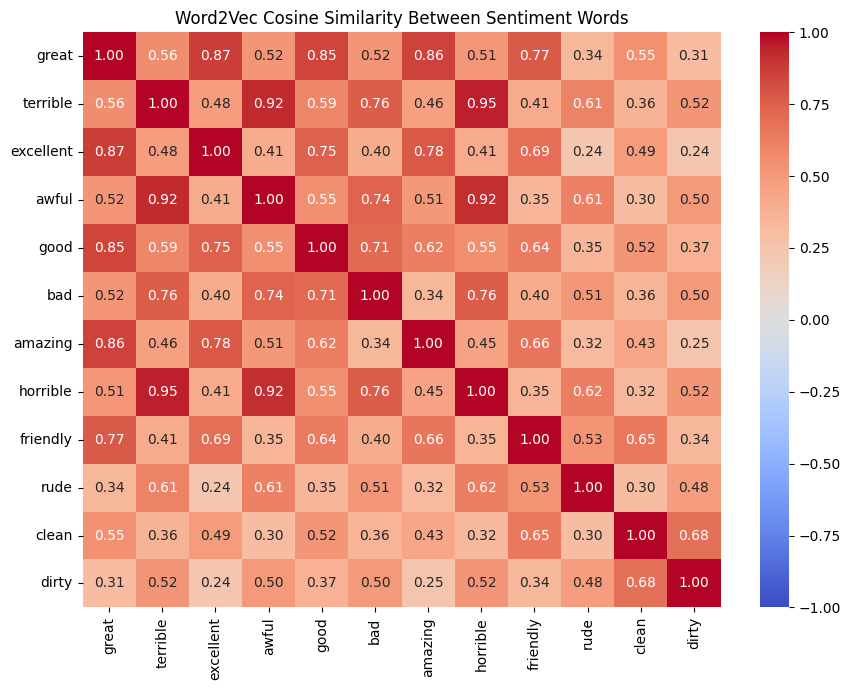


Positive words should cluster together (warm colours) and
negative words should also cluster together, with low similarity across groups.


In [22]:
# visualise word similarities using a heatmap
# picking words that should cluster by sentiment
sentiment_words = ['great', 'terrible', 'excellent', 'awful', 'good', 'bad',
                   'amazing', 'horrible', 'friendly', 'rude', 'clean', 'dirty']

# only keep words that made it into the vocabulary
sentiment_words = [w for w in sentiment_words if w in w2v_model.wv]

similarity_matrix = np.zeros((len(sentiment_words), len(sentiment_words)))
for i, w1 in enumerate(sentiment_words):
    for j, w2 in enumerate(sentiment_words):
        similarity_matrix[i, j] = w2v_model.wv.similarity(w1, w2)

plt.figure(figsize=(9, 7))
sns.heatmap(similarity_matrix, xticklabels=sentiment_words, yticklabels=sentiment_words,
            annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Word2Vec Cosine Similarity Between Sentiment Words')
plt.tight_layout()
plt.show()

print("\nPositive words should cluster together (warm colours) and")
print("negative words should also cluster together, with low similarity across groups.")

---
## 6. Overall Comparison and Summary

In [23]:
# also include binary with bigrams for completeness
bin_bi = CountVectorizer(max_features=10000, binary=True, ngram_range=(1, 2))
acc_bb, f1_bb, _ = evaluate("Binary (bigrams)", bin_bi.fit_transform(X_train), bin_bi.transform(X_test))
results['Binary (bigrams)'] = (acc_bb, f1_bb)

Binary (bigrams)                          Accuracy: 0.6567   F1 (weighted): 0.6252


In [24]:
# print a clean summary table of all results
print(f"{'Representation':<45} {'Accuracy':>10} {'F1 (weighted)':>15}")
print("-" * 72)
for name, (acc, f1) in sorted(results.items(), key=lambda x: x[1][0], reverse=True):
    print(f"{name:<45} {acc:>10.4f} {f1:>15.4f}")

Representation                                  Accuracy   F1 (weighted)
------------------------------------------------------------------------
TF-IDF (1,3) trigrams                             0.6690          0.6324
TF-IDF (1,2) bigrams                              0.6682          0.6309
TF-IDF (unigrams)                                 0.6595          0.6194
TF-IDF (1,1) unigrams                             0.6595          0.6194
Binary (bigrams)                                  0.6567          0.6252
BoW (1,3) trigrams                                0.6547          0.6213
BoW (1,2) bigrams                                 0.6544          0.6211
Binary (unigrams)                                 0.6471          0.6113
BoW Frequency (unigrams)                          0.6458          0.6085
BoW (1,1) unigrams                                0.6458          0.6085
Word2Vec (avg, 300d)                              0.6419          0.5877
Word2Vec (avg, 100d)                              0

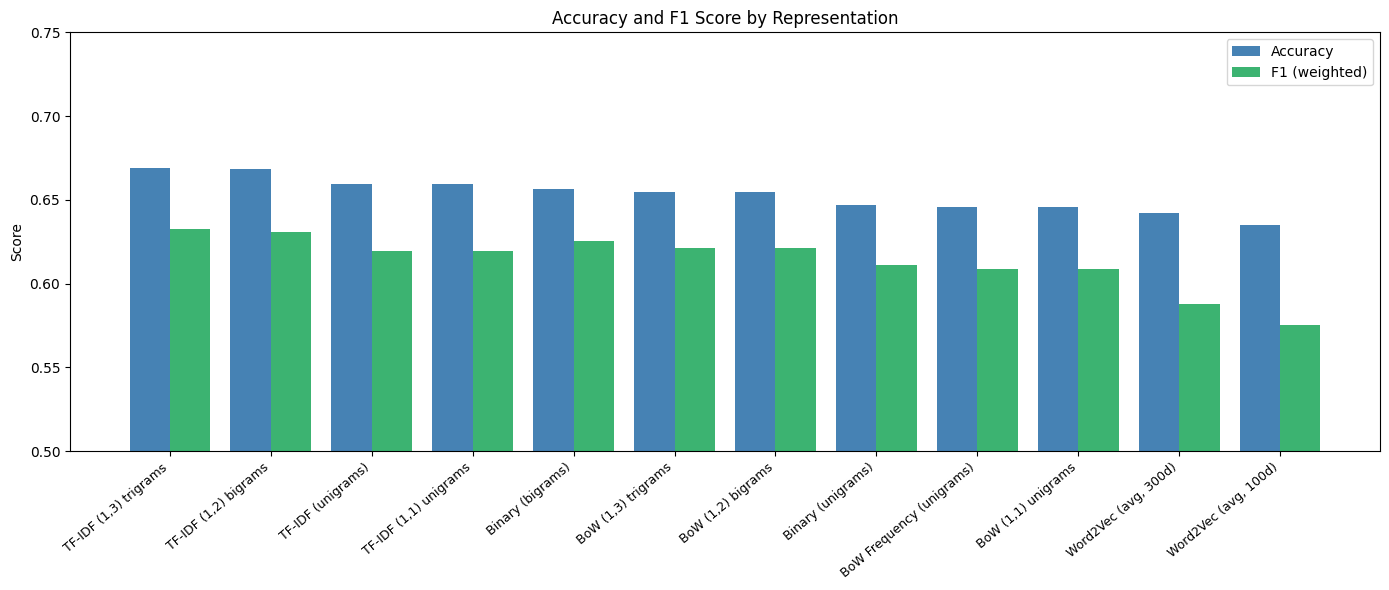

In [25]:
# bar chart of accuracy across all representations
sorted_results = sorted(results.items(), key=lambda x: x[1][0], reverse=True)
labels = [r[0] for r in sorted_results]
accs   = [r[1][0] for r in sorted_results]
f1s    = [r[1][1] for r in sorted_results]

x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
bars_acc = ax.bar(x - width/2, accs, width, label='Accuracy', color='steelblue')
bars_f1  = ax.bar(x + width/2, f1s,  width, label='F1 (weighted)', color='mediumseagreen')

ax.set_ylabel('Score')
ax.set_title('Accuracy and F1 Score by Representation')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=9)
ax.legend()
ax.set_ylim(0.50, 0.75)

plt.tight_layout()
plt.show()

Confusion matrix for best representation: TF-IDF (1,3) trigrams
              precision    recall  f1-score   support

           1       0.75      0.92      0.82     26873
           2       0.39      0.15      0.21      7909
           3       0.41      0.21      0.28      8493
           4       0.64      0.79      0.71     19607
           5       0.68      0.51      0.58      7025

    accuracy                           0.67     69907
   macro avg       0.57      0.51      0.52     69907
weighted avg       0.63      0.67      0.63     69907



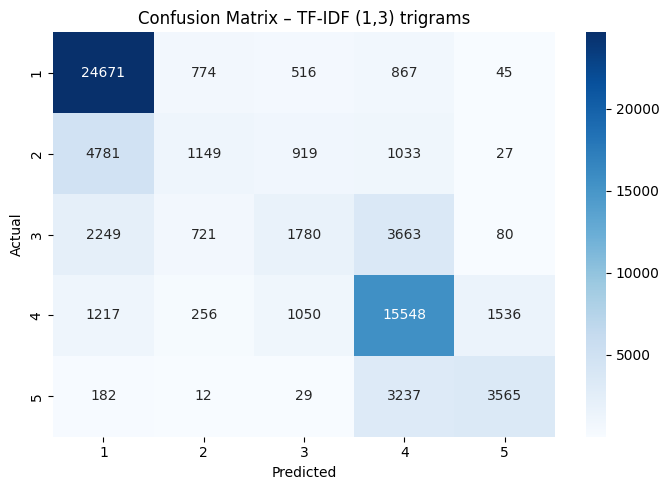

In [26]:
# confusion matrix for the best performing representation
best_name = sorted_results[0][0]
print(f"Confusion matrix for best representation: {best_name}")

# re-fit and predict using the best vectorizer
best_vec = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_tr_best = best_vec.fit_transform(X_train)
X_te_best = best_vec.transform(X_test)

clf_best = LogisticRegression(max_iter=1000, random_state=42)
clf_best.fit(X_tr_best, y_train)
preds_best = clf_best.predict(X_te_best)

print(classification_report(y_test, preds_best))

cm = confusion_matrix(y_test, preds_best)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix – {best_name}')
plt.tight_layout()
plt.show()

## Conclusions

**Full results ranked by accuracy:**

| Representation | Accuracy | F1 (weighted) |
|---|---|---|
| TF-IDF (1,3) trigrams | 0.6690 | 0.6324 |
| TF-IDF (1,2) bigrams | 0.6682 | 0.6309 |
| TF-IDF (1,1) unigrams | 0.6595 | 0.6194 |
| Binary (bigrams) | 0.6567 | 0.6252 |
| BoW (1,3) trigrams | 0.6547 | 0.6213 |
| BoW (1,2) bigrams | 0.6544 | 0.6211 |
| Binary (unigrams) | 0.6471 | 0.6113 |
| BoW (unigrams) | 0.6458 | 0.6085 |
| Word2Vec (300d) | 0.6419 | 0.5877 |
| Word2Vec (100d) | 0.6350 | 0.5752 |

---

**TF-IDF consistently outperforms BoW and Binary:**
TF-IDF came out on top across all n-gram levels. The reason is that words like 'place', 'time',
and 'service' appear heavily across all rating classes, so raw counts just add noise. TF-IDF
down-weights these common words and gives more weight to terms that actually separate the classes,
such as 'disgusting' (1-star) or 'outstanding' (5-star). This confirms TF-IDF is the right choice
for this kind of dataset where some high-frequency words carry very little discriminative value.

**Surprising result — Binary slightly beat BoW for unigrams (0.6471 vs 0.6458):**
This was unexpected. It suggests that for unigram features, the raw count of a word is actually
adding noise rather than signal. A word like 'place' appearing three times in a review versus once
doesn't tell the model much about the rating. Binary sidesteps this entirely by ignoring frequency,
which in this case slightly helps. Once bigrams are added however, BoW recovers and overtakes Binary,
suggesting frequency becomes more useful when phrases are captured as features.

**N-grams improve results, with diminishing returns at trigrams:**
Going from unigrams to bigrams gave a clear improvement across all three representation types.
Bigrams capture meaningful phrases like 'not good', 'highly recommend', and 'never again' that
get completely destroyed when split into individual tokens. TF-IDF trigrams technically achieved
the highest accuracy overall (0.6690), but the gain over bigrams was only 0.0008 — essentially
negligible. With max_features capped at 10,000, trigrams push out some useful unigrams and bigrams
to make room for three-word sequences that appear too rarely to generalise well.

**Word2Vec underperformed all sparse methods:**
Both Word2Vec models (100d: 0.6350, 300d: 0.6419) scored below every BoW/TF-IDF configuration.
The word similarity results were actually very promising — 'terrible' was closest to 'horrible'
(0.949) and 'awful' (0.922), and 'good' was closest to 'great' (0.851) and 'decent' (0.825),
showing the model genuinely learned semantic relationships. The problem is the averaging step.
When you average all word vectors in a review into one vector, you lose word order and relative
emphasis entirely. A strongly negative review ends up with a similar averaged vector to a mixed
review, making classification harder. Increasing dimensions from 100 to 300 helped slightly
(+0.0069 accuracy), confirming that richer representations do help but the averaging bottleneck
remains the main issue. Sequence models like LSTM in Task 5 are designed to avoid this problem
by processing word vectors in order rather than collapsing them.

**Confusion matrix shows the core difficulty of this task:**
Even the best representation (TF-IDF trigrams) only reaches 67% accuracy. The classification
report reveals why — 1-star reviews have strong recall (0.92) because the language is extreme
and distinctive, but 2-star and 3-star reviews are very poorly predicted (F1 of 0.21 and 0.28
respectively). These middle-ground reviews contain mixed language that overlaps across rating
classes, making them genuinely difficult to distinguish even for a human reader.

**Overall best representation for this task:**
TF-IDF with trigrams technically achieved the highest accuracy (0.6690), but the difference
from bigrams (0.6682) is 0.0008 — too small to be meaningful. Given that bigrams are faster
to fit and less likely to overfit due to fewer spurious trigram features making it into the
vocabulary, TF-IDF with bigrams (ngram_range=(1,2)) is the more practical choice to carry
forward into Task 4. Word2Vec embeddings will be revisited in Task 5 where sequence models
can use them properly.